### File Description：

This is a training and testing file.

Input: SEED, it must be set to the same value as the seed used in the dataset to ensure access to the corresponding dataset. The databases are randomly selected and split into training and test sets for cross-validation.

Output: network weights and a result log, they are saved in the corresponding seed's documentation.

### Importing Libraries

In [1]:
import os
import random
import time
import argparse

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import transforms
from torch.utils import data
import torch.nn.init as init
from PIL import Image

import numpy as np
from sklearn.metrics import confusion_matrix
from functools import partial
import matplotlib.pyplot as plt

import vision_transformer
import network_resnet

### Configure

In [2]:
# Fix Random Seeds

SEED = 5216207   # must same as the seed in dataset
NETWORK_STRUCTURE = 'DeiT' # it can be 'DeiT' or 'ResNet50'

def set_seed(seed):
    
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

In [3]:
# Setting global variables
classes = ['noclouds',"clouds"]
lABEL_TO_INDEX = {'noclouds':0, 'clouds':1}
INDX_TO_LABEL = dict((v,k) for k, v in lABEL_TO_INDEX.items())

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [4]:
parser = argparse.ArgumentParser('Cloud_nocloud training and evaluation script')
parser.add_argument('--raw_root', default=r'dataset', type=str)
parser.add_argument('--train_id_path', default=r'SEED_{}/train_id.txt'.format(SEED), type=str)
parser.add_argument('--test_id_path', default=r'SEED_{}/test_id.txt'.format(SEED), type=str)
parser.add_argument('--img_labels_path', default=r'SEED_{}/img_labels.npy'.format(SEED), type=str)
parser.add_argument('--log_path', default=r'SEED_{}/results_log_seed={}.txt'.format(SEED, SEED), type=str)
parser.add_argument('--weight_save', default=r'SEED_{}/weights'.format(SEED), type=str)
parser.add_argument('--nb_classes', default=1, type=int)
parser.add_argument('--batch_size', default=32, type=int)
parser.add_argument('--lr', default=0.0001, type=int)
parser.add_argument('--epochs', default=15, type=int)

args = parser.parse_args([])


if NETWORK_STRUCTURE == 'DeiT':
    args.pre_train = r'preweights/deit_base_patch16_224-b5f2ef4d.pth'
if NETWORK_STRUCTURE == 'ResNet50':
    args.pre_train = r'preweights/resnet50-11ad3fa6.pth'
    

print(args.batch_size)
print(args.pre_train)
print(args.weight_save)
print(args.log_path)
os.makedirs(args.weight_save, exist_ok=True)

32
preweights/deit_base_patch16_224-b5f2ef4d.pth
SEED_5216207/weights
SEED_5216207/results_log_seed=5216207.txt


### Setup Dataset

In [5]:
# Define image transformations/augmentations for training and testing
image_transforms = {
    "train":
        transforms.Compose([
            transforms.RandomResizedCrop(244, scale=(0.8, 1.1)),
            transforms.RandomRotation(degrees=10),
            transforms.ColorJitter(0.4, 0.4, 0.4), # Brightness, contrast, saturation 
            transforms.RandomHorizontalFlip(), 
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], # mean 
                                  [0.229, 0.224, 0.225])  # std
        ]),
    'test':
        transforms.Compose([
        transforms.Resize(size=244),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], 
                              [0.229, 0.224,0.225])
        ]),

}

In [6]:
# Customize my dataset functions

def load_img_name_list(dataset_path):
    img_name_list = open(dataset_path).readlines()
    img_name_list = [img_name.strip() for img_name in img_name_list]

    return img_name_list

def load_image_label_list_from_npy(label_file_path):
    
    cls_labels_dict = np.load(label_file_path, allow_pickle=True).item()

    return cls_labels_dict


class Mydataset(data.Dataset):
    def __init__(self,dataset_root,img_name_list_path,label_file_path,transform):
        
        self.img_name_list = load_img_name_list(img_name_list_path)
        self.label_list = load_image_label_list_from_npy(label_file_path)
        self.transforms = transform
        self.dataset_root = dataset_root
        
    def __getitem__(self,index):
        the_img_name = self.img_name_list[index]
        label = self.label_list[the_img_name]
        
        img_path = os.path.join(self.dataset_root,the_img_name.split('_')[0],the_img_name + '.png')
        
        PIL_image = Image.open(img_path)
        data = self.transforms(PIL_image)
           
        return data, label
    
    def __len__(self):
        return len(self.img_name_list)

# Create datasets for training and testing
datasets = {
        'train' : Mydataset(args.raw_root,args.train_id_path,args.img_labels_path,transform=image_transforms['train']),
        'test' :  Mydataset(args.raw_root,args.test_id_path,args.img_labels_path,transform=image_transforms['test'])
}

# Create dataloaders for batching and shuffling
dataloaders = {
        'train' : data.DataLoader(datasets['train'], batch_size=args.batch_size,shuffle=True),
        'test' : data.DataLoader(datasets['test'], batch_size=args.batch_size,shuffle=False)
}

In [7]:
train_dl = dataloaders['train']
test_dl = dataloaders['test']

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


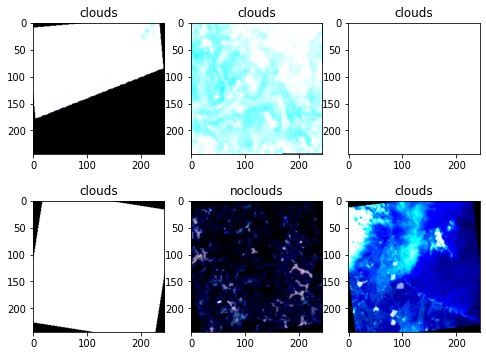

In [8]:
# Sample visualization
img_batch,labels_batch = next(iter(train_dl))
plt.figure(figsize=(8,6))

for i,(img, label) in enumerate(zip(img_batch[:6],labels_batch[:6])):
    img = img.permute(1,2,0).numpy()
    plt.subplot(2,3,i+1)
    plt.title(INDX_TO_LABEL.get(label.item()))
    plt.imshow(img)

### Setup Model

In [9]:
if NETWORK_STRUCTURE == 'DeiT':
    # load deit_base_patch16_224 model, add binary classification by num_classes=2
    my_model = vision_transformer.VisionTransformer(
        patch_size=16,num_classes=args.nb_classes,embed_dim=768, depth=12, num_heads=12, mlp_ratio=4, qkv_bias=True,
        norm_layer=partial(nn.LayerNorm, eps=1e-6)) 

    checkpoint = torch.load(args.pre_train, map_location="cpu",weights_only=True)
    state_dict = checkpoint["model"]

    # Initialize classification head
    init.trunc_normal_(my_model.head.weight, std=0.02)
    init.zeros_(my_model.head.bias)

    # Replace the checkpoint head with this new head
    state_dict['head.weight'] = my_model.head.weight
    state_dict['head.bias'] = my_model.head.bias

    # Load remaining weights
    my_model.load_state_dict(state_dict, strict=True)
    
#     # Freeze all parameters first
#     for param in my_model.parameters():
#         param.requires_grad = False

#     # Unfreeze the FC layer
#     for param in my_model.head.parameters():
#         param.requires_grad = True
    
if NETWORK_STRUCTURE == 'ResNet50':
    my_model = network_resnet.ResNet50(args.nb_classes)
    
    state_dict = torch.load(args.pre_train)
    
    init.trunc_normal_(my_model.fc.weight, std=0.02)
    init.zeros_(my_model.fc.bias)
    
    # Replace the checkpoint head with this new head
    state_dict['fc.weight'] = my_model.fc.weight
    state_dict['fc.bias'] = my_model.fc.bias
    
    my_model.load_state_dict(state_dict, strict=True)
    
#     # Freeze all parameters first
#     for param in my_model.parameters():
#         param.requires_grad = False

#     # Unfreeze the FC layer
#     for param in my_model.fc.parameters():
#         param.requires_grad = True
    
#         # Unfreeze the FC layer
#     for param in my_model.layer4.parameters():
#         param.requires_grad = True

In [10]:
my_model.to(DEVICE)

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (head): Linear(in_featu

### Setup Training Process

In [11]:
# Create the optimizer
optim = torch.optim.Adam(filter(lambda p: p.requires_grad, my_model.parameters()), lr=args.lr)
# Define the loss function
loss_fn = nn.BCEWithLogitsLoss()
# Set up a learning rate scheduler
exp_lr_scheduler = lr_scheduler.StepLR(optim, step_size=5, gamma=0.8)

In [12]:
# Display training progress bar
class Progress_bar():
    max_bar = 40
        
    def __init__(self, batch_size, lenofdata):
        
        self.i = 1
        self.eachstep = batch_size
        self.max_steps = lenofdata//batch_size
        
    def show_percent(self):
        
        percent= self.i*100//self.max_steps
        
        num_star  = self.max_bar * self.i//self.max_steps
        num_bar = self.max_bar-(num_star)

        print( '|','-' *num_star ,'.'*num_bar,'|', percent,'%',end='\r' )
       
        self.i += 1
        
        if self.i >= self.max_steps+2:
            self.close()
            
    def close(self):
        print(' '*200,end = '\r' )
        self.i = 1

In [13]:
# Define training funtion
def Train(model,device,train_loader,loss_function,optimizer,show_pro):
    
    # instantiating the progress bar object
    printoutproceesing = show_pro(train_loader.batch_size,train_loader.dataset.__len__())
    print( '|',' '*40,'|', 0,'%',end='\r' )
    
    all_preds = []
    all_labels = []
    train_running_loss = 0
    
    model.train()
    for imgs, labels in train_loader:
        imgs = imgs.float().to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        y_pred = model(imgs) # forward pass
        loss = loss_function(y_pred,labels)
        loss.backward()
        optim.step()
        
        # accumulate loss
        train_running_loss += loss.item() * imgs.size(0)  # multiply by batch size
    
        # convert logits to predicted classes
        probs = torch.sigmoid(y_pred)
        preds = (probs > 0.5).long()

        # store all predictions and labels for metrics
        all_preds.append(preds.cpu())
        all_labels.append(labels.long().cpu())
        
        # updates progress display
        printoutproceesing.show_percent() 
    
    exp_lr_scheduler.step()
    
    # Concatenate all predictions and labels
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    # Compute confusion matrix
    from sklearn.metrics import confusion_matrix
    train_cm = confusion_matrix(all_labels.numpy(), all_preds.numpy())

    # Average loss per sample
    train_loss = train_running_loss / len(train_loader.dataset)

    return train_loss, train_cm

In [14]:
# Define test funtion
def Evaluate(model, device,test_loader,loss_function,show_pro):
    
    
    printout = show_pro(test_loader.batch_size,test_loader.dataset.__len__())
    print( '|',' '*40,'|', 0,'%',end='\r' )
    
    all_preds = []
    all_labels = []
    test_running_loss = 0.5
        
    model.eval()
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.float().to(device)
            labels = labels.float().unsqueeze(1).to(device)
            
            # forward pass
            y_pred = model(imgs) # forward pass

            # convert logits to predicted classes
            probs = torch.sigmoid(y_pred)
            preds = (probs > 0.5).long()
            
            
            # accumulate predictions and labels for metrics
            all_preds.append(preds.cpu())
            all_labels.append(labels.long().cpu())
            
            printout.show_percent()
            
    # Concatenate all batches
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    
    # Confusion matrix
    test_cm = confusion_matrix(all_labels.numpy(), all_preds.numpy())

    return test_cm

In [15]:
def calculate_pre_rec_acc_f1(cm):
    
    TN, FP = cm[0,0], cm[0,1]
    FN, TP = cm[1,0], cm[1,1]
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    accuracy = (TP + TN) / (TP + TN + FP + FN)

    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return precision,recall,accuracy,f1

In [16]:
def print_log(log_path, *args):
    # print to Jupyter
    print(*args)

    # print to txt
    with open(log_path, "a") as f:
        print(*args, file=f)

In [17]:
# Define training process
def Train_epochs(epochs,model,device,train_loader, test_loader,loss_function,optimizer,show_pro):

    start = time.time()
    
    for epoch in range(epochs):
        # Training 
        train_loss,train_cm = Train(model,device,train_loader,loss_function,optimizer,show_pro)
        precision,recall,accuracy,f1 = calculate_pre_rec_acc_f1(train_cm)
        # Record results txt
        print_log(args.log_path, f"Epoch: {epoch}")
        print_log(args.log_path, f"Training loss: {train_loss:.5f}")
        print_log(
            args.log_path,
            f"Training Accuracy: {accuracy:.4f} | "
            f"Precision: {precision:.4f} | "
            f"Recall: {recall:.4f} | "
            f"F1-score: {f1:.4f}"
        )
        # Testing
        test_cm = Evaluate(model, device, test_loader,loss_function,show_pro)
        precision,recall,accuracy,f1 = calculate_pre_rec_acc_f1(test_cm)
        
        # Record results to txt
        print_log(
            args.log_path,
            f"Test Accuracy: {accuracy:.4f} | "
            f"Precision: {precision:.4f} | "
            f"Recall: {recall:.4f} | "
            f"F1-score: {f1:.4f}\n"
        )
        
        # Save weights
        torch.save(model.state_dict(),os.path.join(args.weight_save,f"checkpoint_{epoch}_{round(f1,4)}.pth"))
    
    time_all = time.time() - start

    print_log(
        args.log_path,
        "Training complete in {:.2f}m {:.2f}s".format(
            time_all // 60, time_all % 60)
        )

In [ ]:
# Seed = 5216207
Train_epochs(args.epochs,my_model,DEVICE,train_dl,test_dl,loss_fn,optim,Progress_bar)

### Training Records

In [53]:
# Seed = 5216207
Train_epochs(args.epochs,my_model,DEVICE,train_dl,test_dl,loss_fn,optim,Progress_bar)

epoch: 0                                                                     
training loss: 0.09624
Training Accuracy: 0.9696 | Precision: 0.9703 | Recall: 0.9689 | F1-score: 0.9696
Test Accuracy: 0.9836 | Precision: 0.9815 | Recall: 0.9857 | F1-score: 0.9836                                                                                                                           
epoch: 1                                                                     
training loss: 0.07257
Training Accuracy: 0.9786 | Precision: 0.9748 | Recall: 0.9825 | F1-score: 0.9787
Test Accuracy: 0.9779 | Precision: 0.9785 | Recall: 0.9771 | F1-score: 0.9778                                                                                                                           
epoch: 2                                                                     
training loss: 0.05953
Training Accuracy: 0.9832 | Precision: 0.9781 | Recall: 0.9886 | F1-score: 0.9833
Test Accuracy: 0.9857 | Precision: 0.9762 | Recal

In [36]:
# Seed = 567
Train_epochs(args.epochs,my_model,DEVICE,train_dl,test_dl,loss_fn,optim,Progress_bar)

epoch: 0                                                                     
training loss: 0.0895
Training Accuracy: 0.9741 | Precision: 0.9709 | Recall: 0.9775 | F1-score: 0.9742
Test Accuracy: 0.9750 | Precision: 0.9536 | Recall: 0.9986 | F1-score: 0.9756                                                                                                                           
epoch: 1                                                                     
training loss: 0.07096
Training Accuracy: 0.9800 | Precision: 0.9742 | Recall: 0.9861 | F1-score: 0.9801
Test Accuracy: 0.9871 | Precision: 0.9858 | Recall: 0.9886 | F1-score: 0.9872                                                                                                                           
epoch: 2                                                                     
training loss: 0.06529
Training Accuracy: 0.9818 | Precision: 0.9770 | Recall: 0.9868 | F1-score: 0.9819
Test Accuracy: 0.9879 | Precision: 0.9858 | Recall

In [18]:
# Seed = 295
Train_epochs(args.epochs,my_model,DEVICE,train_dl,test_dl,loss_fn,optim,Progress_bar)

epoch: 0                                                                     
training loss: 0.09701
Training Accuracy: 0.9695 | Precision: 0.9696 | Recall: 0.9693 | F1-score: 0.9695
Test Accuracy: 0.9836 | Precision: 0.9801 | Recall: 0.9871 | F1-score: 0.9836                                                                                                                           
epoch: 1                                                                     
training loss: 0.06292
Training Accuracy: 0.9805 | Precision: 0.9773 | Recall: 0.9839 | F1-score: 0.9806
Test Accuracy: 0.9857 | Precision: 0.9802 | Recall: 0.9914 | F1-score: 0.9858                                                                                                                           
epoch: 2                                                                     
training loss: 0.05879
Training Accuracy: 0.9852 | Precision: 0.9816 | Recall: 0.9889 | F1-score: 0.9852
Test Accuracy: 0.9757 | Precision: 0.9549 | Recal

In [26]:
# Seed = 42
Train_epochs(args.epochs,my_model,DEVICE,train_dl,test_dl,loss_fn,optim,Progress_bar)

epoch: 0                                                                     
training loss: 0.09158
Training Accuracy: 0.9736 | Precision: 0.9709 | Recall: 0.9764 | F1-score: 0.9736
Test Accuracy: 0.9793 | Precision: 0.9898 | Recall: 0.9686 | F1-score: 0.9791                                                                                                                           
epoch: 1                                                                     
training loss: 0.06872
Training Accuracy: 0.9805 | Precision: 0.9770 | Recall: 0.9843 | F1-score: 0.9806
Test Accuracy: 0.9836 | Precision: 0.9829 | Recall: 0.9843 | F1-score: 0.9836                                                                                                                           
epoch: 2                                                                     
training loss: 0.06016
Training Accuracy: 0.9827 | Precision: 0.9784 | Recall: 0.9871 | F1-score: 0.9828
Test Accuracy: 0.9814 | Precision: 0.9870 | Recal

In [17]:
# Seed = 2026
Train_epochs(args.epochs,my_model,DEVICE,train_dl,test_dl,loss_fn,optim,Progress_bar)

epoch: 0                                                                     
training loss: 0.09724
Training Accuracy: 0.9750 | Precision: 0.9720 | Recall: 0.9782 | F1-score: 0.9751
Test Accuracy: 0.9586 | Precision: 0.9820 | Recall: 0.9343 | F1-score: 0.9575                                                                                                                           
epoch: 1                                                                     
training loss: 0.07387
Training Accuracy: 0.9793 | Precision: 0.9749 | Recall: 0.9839 | F1-score: 0.9794
Test Accuracy: 0.9857 | Precision: 0.9789 | Recall: 0.9929 | F1-score: 0.9858                                                                                                                           
epoch: 2                                                                     
training loss: 0.05903
Training Accuracy: 0.9848 | Precision: 0.9809 | Recall: 0.9889 | F1-score: 0.9849
Test Accuracy: 0.9871 | Precision: 0.9830 | Recal